Construct - Build a Causal Model to Quantify the Effect of Sales Outreach on Feature Adoption

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from dowhy import CausalModel
from sklearn.model_selection import train_test_split


In [163]:
root = Path().resolve().parents[0] if Path().resolve().name == "notebooks" else Path().resolve()
dfr = root / "data" / "processed" / "analysis_ready.csv"
df = pd.read_csv(dfr,low_memory=False)


# Propensity score overlap

In [164]:
Predictors = ['DECILE','TOTAL_ORDERS_SINCE_INCEPTION', 'FBA_RATIO', 'TIME_TO_LAUNCHED',  'NO_OF_WAREHOUSES', 'NO_OF_USERS','UNIQUE_CHANNELS']
treatment = df['HAS_SALES_TOUCH']

quick check

In [165]:
treated = df[df['HAS_SALES_TOUCH'] == 1]
control = df[df['HAS_SALES_TOUCH'] == 0]


In [166]:
from scipy.stats import ttest_ind
print(control['TOTAL_ORDERS_SINCE_INCEPTION'].mean())
print(treated['TOTAL_ORDERS_SINCE_INCEPTION'].mean())
_, p = ttest_ind(control['TOTAL_ORDERS_SINCE_INCEPTION'], treated['TOTAL_ORDERS_SINCE_INCEPTION'])
print(f"P-value: {p:.3f}")

1862.9041628911039
30178.149994436408
P-value: 0.000


In [167]:
lgr = LogisticRegression(max_iter=1000)
lgr.fit(df[Predictors], treatment)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [168]:
lgr.coef_.ravel()


array([-6.54886091e-01, -1.57343653e-07,  1.06448305e+00,  9.77697427e-04,
        4.68106591e-06,  3.63351919e-02,  0.00000000e+00])

In [169]:
df['propensity_score'] = lgr.predict_proba(df[Predictors])[:, 1]

In [170]:
treated = df[df['HAS_SALES_TOUCH'] == 1].copy()
control = df[df['HAS_SALES_TOUCH'] == 0].copy()
outcome = 'TOTAL_ORDERS_YTD'
mean_t = df[df['HAS_SALES_TOUCH'] == 1][outcome].mean()
mean_c = df[df['HAS_SALES_TOUCH'] == 0][outcome].mean()
print(f"Mean outcome for treated: {mean_t:.2f}")
print(f"Mean outcome for control: {mean_c:.2f}")
gap = mean_t - mean_c

Mean outcome for treated: 8778.22
Mean outcome for control: 531.74


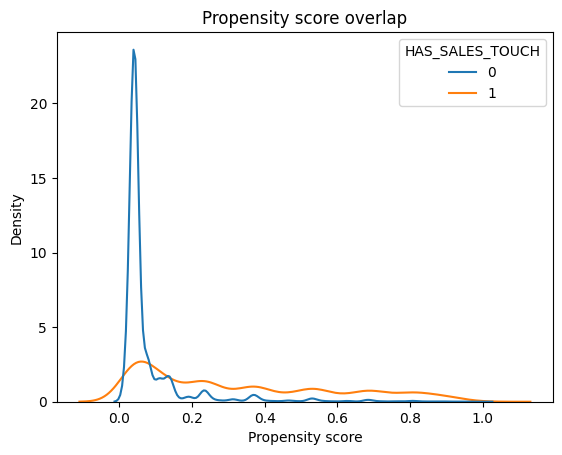

In [171]:
sns.kdeplot(data=df, x='propensity_score', hue='HAS_SALES_TOUCH', common_norm=False)
plt.title('Propensity score overlap')
plt.xlabel('Propensity score')
plt.show()

SMD_RESULTS

In [172]:
smd_results = {}
for col in Predictors:
    mean_t = treated[col].mean()
    mean_c = control[col].mean()
    var_t = treated[col].var()
    var_c = control[col].var()
    pooled_std = np.sqrt((var_t + var_c) / 2)
    if pooled_std > 0:
        smd = (mean_t - mean_c) / pooled_std
    else:
        smd = 0
    smd_results[col] = abs(smd)

smd_df = pd.DataFrame(list(smd_results.items()), columns=['Confounder', 'SMD'])
print(smd_df)

                     Confounder       SMD
0                        DECILE  1.274890
1  TOTAL_ORDERS_SINCE_INCEPTION  0.327755
2                     FBA_RATIO  0.331302
3              TIME_TO_LAUNCHED  0.324924
4              NO_OF_WAREHOUSES  0.027706
5                   NO_OF_USERS  0.209090
6               UNIQUE_CHANNELS  0.000000


Matching

In [173]:
from sklearn.neighbors import NearestNeighbors

treated = df[df['HAS_SALES_TOUCH'] == 1].copy()
control = df[df['HAS_SALES_TOUCH'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])

used = set()
matches = []
for i, treated_idx in enumerate(treated.index):
    control_position = indices[i][0]
    control_idx = control.iloc[control_position].name
    if control_idx not in used:
        matches.append((treated_idx, control_idx))
        used.add(control_idx)

matched_treated = df.loc[[p[0] for p in matches]].copy()
matched_control = df.loc[[p[1] for p in matches]].copy()
print(f"Number of matched pairs: {len(matches)}")

Number of matched pairs: 5427


SMD_MATCHED

In [174]:
smd_matched = {}
for col in Predictors:
    mean_t = matched_treated[col].mean()
    mean_c = matched_control[col].mean()
    var_t = matched_treated[col].var()
    var_c = matched_control[col].var()
    pooled_std = np.sqrt((var_t + var_c) / 2)
    if pooled_std > 0:
        smd = (mean_t - mean_c) / pooled_std
    else:
        smd = 0
    smd_matched[col] = abs(smd)

smd_df_matched = pd.DataFrame(list(smd_matched.items()), columns=['Confounder', 'SMD (matched)'])
print(smd_df_matched)

                     Confounder  SMD (matched)
0                        DECILE       0.005931
1  TOTAL_ORDERS_SINCE_INCEPTION       0.062810
2                     FBA_RATIO       0.023862
3              TIME_TO_LAUNCHED       0.033463
4              NO_OF_WAREHOUSES       0.006948
5                   NO_OF_USERS       0.065149
6               UNIQUE_CHANNELS       0.000000


Average difference beetwen matched treated and control accounts

In [175]:
att = matched_treated[outcome].mean() - matched_control[outcome].mean()
print(f"ATT (Oredrs_YTD): {att:.2f}")

ATT (Oredrs_YTD): 1059.45


For the accounts that actually received a sales touch, the touch is associated with approximately 1,059 additional year‑to‑date orders, compared to what they would have done without the touch

Baseline OLS on Matched Data

In [176]:
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
matched_data = pd.concat([matched_treated, matched_control], axis=0)
X_matched = matched_data[Predictors + ['HAS_SALES_TOUCH']]
X_matched = sm.add_constant(X_matched)
y_matched = matched_data[outcome]
ols_matched = sm.OLS(y_matched, X_matched).fit()
print(ols_matched.summary())

                            OLS Regression Results                            
Dep. Variable:       TOTAL_ORDERS_YTD   R-squared:                       0.580
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     2141.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:43:37   Log-Likelihood:            -1.1827e+05
No. Observations:               10854   AIC:                         2.366e+05
Df Residuals:                   10846   BIC:                         2.366e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

c:\Users\User\source\repos\PLG_SAAS_ANALYSIS\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


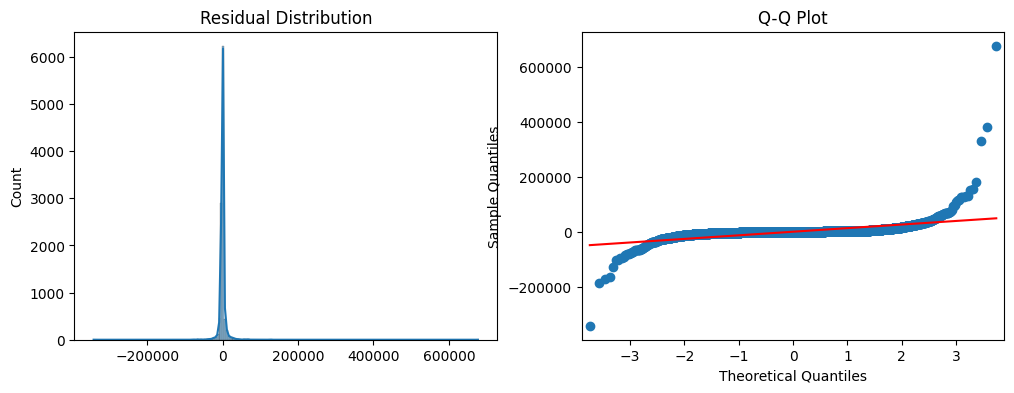

In [177]:
residuals = ols_matched.resid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution')
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot')
plt.show()

Comparison with full data

In [178]:
X_full = df[Predictors + ['HAS_SALES_TOUCH']]
X_full = sm.add_constant(X_full)
y_full = df[outcome]
ols_full = sm.OLS(y_full, X_full).fit()
print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:       TOTAL_ORDERS_YTD   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                 1.266e+04
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:43:37   Log-Likelihood:            -8.9308e+05
No. Observations:               84031   AIC:                         1.786e+06
Df Residuals:                   84023   BIC:                         1.786e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

c:\Users\User\source\repos\PLG_SAAS_ANALYSIS\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


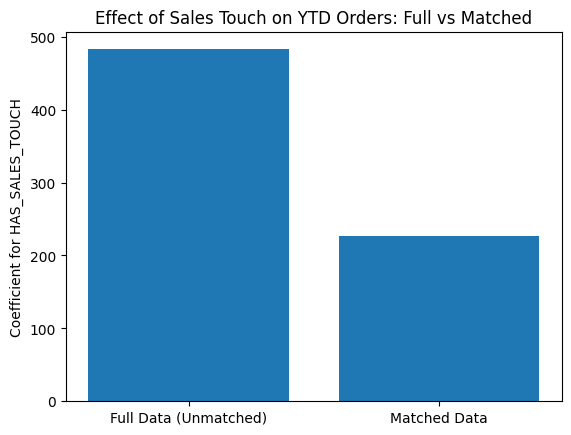

In [179]:
coefs = [ols_full.params['HAS_SALES_TOUCH'], ols_matched.params['HAS_SALES_TOUCH']]
labels = ['Full Data (Unmatched)', 'Matched Data']
plt.bar(labels, coefs)
plt.ylabel('Coefficient for HAS_SALES_TOUCH')
plt.title('Effect of Sales Touch on YTD Orders: Full vs Matched')
plt.show()

Quantile Regression on Matched Data

In [185]:
from statsmodels.regression.quantile_regression import QuantReg
quantiles = [0.1, 0.5, 0.9]
coefs = []
valid_quantiles = []

for q in quantiles:
    try:
        mod = QuantReg(y_matched, X_matched)
        res = mod.fit(q=q, max_iter=2000)  # increase iterations
        coefs.append(res.params['HAS_SALES_TOUCH'])
        valid_quantiles.append(q)
        print(f"Quantile {q*100:.0f}%: {res.params['HAS_SALES_TOUCH']:.2f}")
    except Exception as e:
        print(f"Quantile {q*100:.0f}% failed: {e}")

Quantile 10%: 0.00


c:\Users\User\source\repos\PLG_SAAS_ANALYSIS\venv\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


Quantile 50%: 111.67
Quantile 90%: 263.22


c:\Users\User\source\repos\PLG_SAAS_ANALYSIS\venv\Lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (2000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


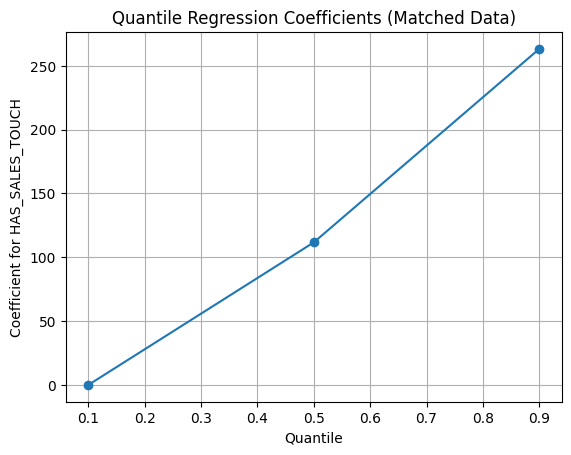

In [186]:
plt.plot(valid_quantiles, coefs, marker='o')
plt.xlabel('Quantile')
plt.ylabel('Coefficient for HAS_SALES_TOUCH')
plt.title('Quantile Regression Coefficients (Matched Data)')
plt.grid(True)
plt.show()

In [182]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
orders_scaled = scaler.fit_transform(df[[outcome]])
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(orders_scaled)
cluster_medians = df.groupby('cluster')[outcome].median()
high_cluster = cluster_medians.idxmax()
low_cluster = cluster_medians.idxmin()
df['cluster_label'] = df['cluster'].map({high_cluster: 'High', low_cluster: 'Low'})
print("Cluster medians:\n", cluster_medians)

Cluster medians:
 cluster
0         0.0
1    589040.0
Name: TOTAL_ORDERS_YTD, dtype: float64


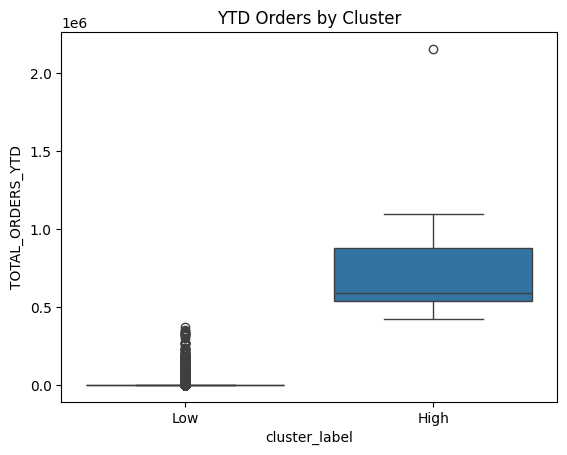

In [183]:
sns.boxplot(data=df, x='cluster_label', y=outcome)
plt.title('YTD Orders by Cluster')
plt.show()

In [184]:
matched_data['cluster_label'] = df.loc[matched_data.index, 'cluster_label']
for cluster in ['High', 'Low']:
    sub = matched_data[matched_data['cluster_label'] == cluster]
    if len(sub) > 0:
        att = sub[sub['HAS_SALES_TOUCH'] == 1][outcome].mean() - sub[sub['HAS_SALES_TOUCH'] == 0][outcome].mean()
        print(f"ATT for {cluster} orders cluster: {att:.0f}")

ATT for High orders cluster: 264845
ATT for Low orders cluster: 717
